<a href="https://colab.research.google.com/github/Tahsin22201243/Machine-Learning/blob/main/SetA_22201243.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A Qns 1

In [13]:

import numpy as np
import pandas as pd

In [14]:
df = pd.read_csv('/content/Telco_Customer_Churn.csv')


In [17]:
col = df['tenure']

In [18]:
mean = np.mean(col)
std = np.std(col)

In [19]:
outlies= (col>mean+3*std) | (col<mean-3*std)
outlies_count = np.sum(outlies)
print(outlies_count)

0


In [21]:
median =np.median(col)
df.loc[outlies,'tenure'] = median
df['loyality_flag'] = np.where(df['tenure']>48,1,0)

In [22]:
print("Outliers Count:",outlies_count)
print(df.head())

Outliers Count: 0
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... TechSupport  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...         Yes   
4                No     Fiber optic             No  ...          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0       

Qns 2

In [28]:
contract_map={
    'Month-to-month':1,
    'One year':2,
    'Two year':3
}
df['contract_type']=df['contract'].map(contract_map)
df_encoded = pd.get_dummies(df,columns=['payment_method'])
print("New Shape:",df_encoded.shape)


KeyError: 'contract'

Qns 3

In [24]:
threshold =0.05*len(df)
df =df.loc[:,df.isnull().sum()<=threshold]

df['service_type']=df['service_type'].str.strip().str.upper()
print(df.isnull().sum())

KeyError: 'service_type'

Part B Qns 4

```
# This is formatted as code
```



In [51]:
pivot=pd.pivot_table(
    df,
    values='tenure',
    index='gender',
    columns='contract',
    aggfunc='mean'
)
print(pivot)

KeyError: 'contract'

Qns 8

1.RMSE squares erros than penalizes large erros more heavily
MAE treats all erros equally
so RMSE is better when large mistake are costly

2. Overfitting
High R^2 + High test erros means:
Model fits training data on new data

Qns 5

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

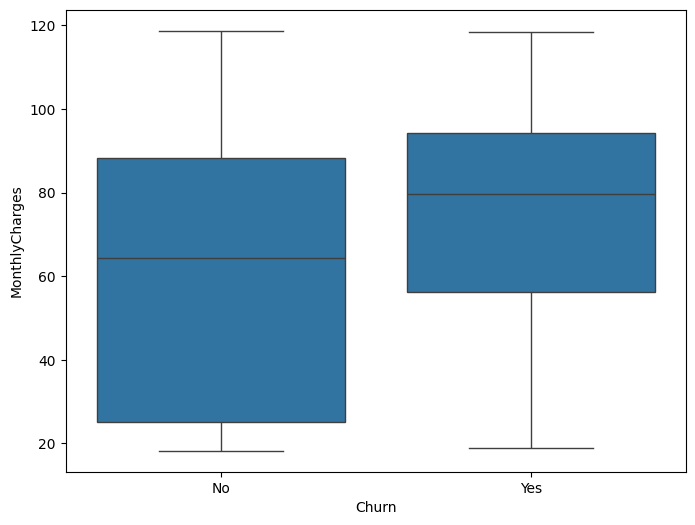

In [30]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

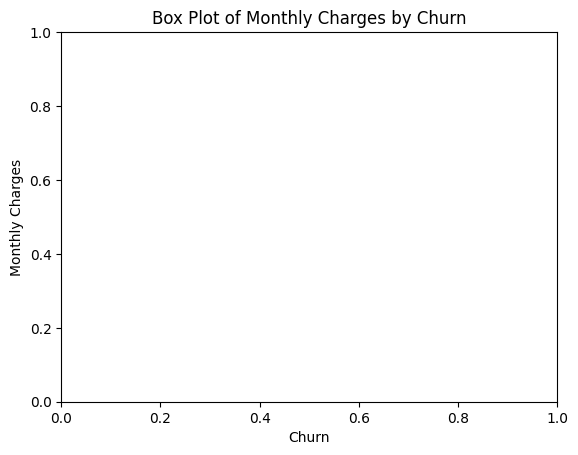

In [31]:
plt.title('Box Plot of Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Qns 6

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0}) # Convert 'Yes' to 1 and 'No' to 0


X = pd.get_dummies(X, drop_first=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  loyality_flag  \
0              0       1           29.85         29.85              0   
1              0      34           56.95       1889.50              0   
2              0       2           53.85        108.15              0   
3              0      45           42.30       1840.75              0   
4              0       2           70.70        151.65              0   

   customerID_0003-MKNFE  customerID_0004-TLHLJ  customerID_0011-IGKFF  \
0                  False                  False                  False   
1                  False                  False                  False   
2                  False                  False                  False   
3                  False                  False                  False   
4                  False                  False                  False   

   customerID_0013-EXCHZ  customerID_0013-MHZWF  ...  \
0                  False                  False  ...   
1   

Scaling features, such as tenure (in months) and TotalCharges (potentially in thousands), is crucial for the convergence of a logistic regression model for several reasons, primarily related to the optimization algorithm (gradient descent):

1.Equal Contribution to Gradient Descent: Logistic regression

2.Faster and More Stable Convergence: Unequal gradients cause the optimization process to 'zig-zag' toward the minimum of the cost function.

3.Numerical Stability: Very large or very small feature values can lead to numerical instability during calculations, especially with floating-point arithmetic.

4.Regularization Impact

Qns 7

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score



In [56]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:",roc_auc_score(y_test,y_pred))


[[1096  186]
 [ 156  323]]
              precision    recall  f1-score   support

          No       0.88      0.85      0.87      1282
         Yes       0.63      0.67      0.65       479

    accuracy                           0.81      1761
   macro avg       0.75      0.76      0.76      1761
weighted avg       0.81      0.81      0.81      1761



ValueError: could not convert string to float: 'Yes'